In [101]:
import math
import matplotlib.pyplot as plt
import numpy as np
from qiskit.circuit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library.standard_gates import RYGate
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem, FasterAmplitudeEstimation
from itertools import product
from scipy.stats import norm, lognorm


# **Authors**: Fadwa Ed-daoudy - Hicham Ettahri

# Standard pricing of a call option

The first part of this project consists in computing the price of a call option using the Black-Scholes closed formula, and then approximating it using a Monte Carlo method.

## Black-Scholes price of the call option

We first compute the price of a European call option using the classical Black-Scholes formula. This serves as a reference value that we will later compare with the result obtained using a quantum approach.

A call option gives the right (but not the obligation) to buy an asset at a fixed price $K$ (the strike) at maturity $T$. Its payoff is:
$\max(S_T - K, 0)$

The Black-Scholes formula provides a closed-form (analytical) expression for the price of this option.

The parameters used are:
- $S_0$: initial price of the asset  
- $K$: strike price  
- $r$: risk-free interest rate  
- $\sigma$: volatility of the asset  
- $T$: time to maturity  

The price $C$ of the call option is given by:
$$
C = S_0 N(d_1) - K e^{-rT} N(d_2)
$$

where:
$$
d_1 = \frac{\ln(S_0 / K) + (r + \sigma^2 / 2) T}{\sigma \sqrt{T}}
$$
$$
d_2 = \frac{\ln(S_0 / K) + (r - \sigma^2 / 2) T}{\sigma \sqrt{T}} = d_1 - \sigma \sqrt{T}
$$

In the following, we will aim to recover this price using a quantum algorithm based on expectation estimation.


Definition of the function implementing the closed formula for the price of a call option

In [102]:
def black_scholes_call(S, K, T, r, sigma):
    """
    Calculate the Black-Scholes price for a European call option.
    
    :param S: Current stock price
    :param K: Strike price
    :param T: Maturity (in years)
    :param r: Risk-free interest rate (annual)
    :param sigma: Volatility of the stock (annual)
    :return: Call option price
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

### Characteristics to price the call option

In [103]:
# Financial characteristics that are also required to compute the probability distribution
sigma = 0.2 # volatility (annualized)
T = 1 # maturity (in years)
r = 0.05 # risk-free rate (annualized)
S0 = 2 # initial stock price
K = 2 # strike price

Evaluation of the price for the given set of parameters

In [104]:
call_price = black_scholes_call(S0, K, T, r, sigma)
print(f"Call option price: {call_price}")

Call option price: 0.20901167144371136


## Compounded Black-Scholes price of the call option

In this project, we are actually interested in the compounded value of the call price. Data is stored in dictionaries.

The Black-Scholes price is a discounted expectation. Since the quantum algorithm estimates the undiscounted payoff $\mathbb{E}[\max(S_T - K, 0)]$, we multiply the classical price by $e^{rT}$ to obtain a comparable quantity.

Dictionary for the pricing characteristics

In [105]:
price_dict = {'S0': S0, 'r': r, 'sigma': sigma, 'T': T}

In [106]:
def compound_black_scholes_call(price_dict, K):
    """
    Calculate the Black-Scholes price for a European call option.
    
    :param S: Current stock price
    :param K: Strike price
    :param T: Maturity (in years)
    :param r: Risk-free interest rate (annual)
    :param sigma: Volatility of the stock (annual)
    :return: Call option price
    """
    S0 = price_dict['S0']
    T = price_dict['T']
    r = price_dict['r']
    sigma = price_dict['sigma']
    call_price = black_scholes_call(S0, K, T, r, sigma)
    compound = np.exp(r * T)
    return compound * call_price

In [107]:
compound_call_price = compound_black_scholes_call(price_dict, K)
print(f"Compounded call option price: {compound_call_price}")

Compounded call option price: 0.21972792899401578


The compounded call option price is approximately $0.220$, corresponding to the risk-neutral expectation of the payoff $\max(S_T - K, 0)$

## Monte Carlo evaluation of the compounded price of the call option

Complete the code below to evaluate the compounded price of the call option. A sample of $\mathcal{N}(0,1)$ can be generated using the command `random.standard_normal` from **numpy**

In [108]:
def monte_carlo_black_scholes(price_dict, K, num_simulations):
    """
    Monte Carlo simulation for Black-Scholes option pricing.
    
    :param price_dict: Dictionary containing the pricing characteristics
    :param K: Strike price
    :param num_simulations: Number of Monte Carlo simulations
    :return: Option price
    """
    S = price_dict['S0']
    T = price_dict['T']
    r = price_dict['r']
    sigma = price_dict['sigma']

    Z = np.random.normal(0, 1, num_simulations) # standard normal RV


    ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    payoffs = np.maximum(ST - K, 0)

    option_price = np.mean(payoffs)    
    return option_price

**NB**: Instead of the exact formula in the slides, we used `np.mean()`

In [109]:
monte_carlo_black_scholes(price_dict, K, 50000)

np.float64(0.22138301514090464)

The goal of the project is to implement a quantum algorithm that can be used to approximate the compounded price.

# Storing a linear function in a quantum state

## Presentation
The goal of this part is to construct a circuit that permits to encode an affine function $f: x\mapsto a + bx$ on $n$ qubits, under the constraint that $a$ and $b$ are such that $f(x) \in [0,1]$ for all $x\in \{0, \ldots, 2^n-1\}$.

The encoding is based on the approximation $\sin^2\left(y + \frac{\pi}{4}\right) = y + \frac{1}{2} + O\left(y^3\right)$, where $y$ is replaced by $d\cdot\left(f(x) + \frac{1}{2}\right)$.

## Encoding the affine function

Create a method `encode_affine_function`$(n,a,b)$ that encodes the function $f$ defined above using rotation gates. Recall that the circuit consists of $n+1$ qubits.

In [110]:
def encode_affine_function(n, a, b):
    """
    Encode the affine function g(x) = a + b*x on a circuit with n+1 qubits.

    Convention used here:
    - q0 is the output qubit
    - q1, ..., qn are the input qubits
    """
    qc = QuantumCircuit(n + 1)

    output = 0  # output qubit is q0

    # constant part of the affine function
    qc.ry(2 * a, output)

    # add the contribution of each input bit
    for k in range(n):
        angle = 2 * (2**k) * b
        qc.cry(angle, k + 1, output)

    return qc

## Testing the circuit

The goal of this part is to make sure that the designed circuit behaves as expected for all inputs.

### Helper functions for amplitude estimation on the constructed circuit

The functions below are provided so that they can be used to make sure the constructed circuit behaves as expected.

In [111]:
def to_bin(n, i):
    """
    Convert integer i to binary string of length n and append '1' to the end.
    """
    bini = format(i, f'0{n}b')
    res = bini + '1'
    return res

In [112]:
def get_state_probabilities(qc):
  """
  Retrieve the probabilities of each basis state from the statevector of the input quantum circuit.
  """
  n = qc.num_qubits
  statevector = Statevector(qc)
  probabilities = {}
  for i in range(2**n):
    state = bin(i)[2:].zfill(n)
    probabilities[state] = abs(statevector[i])**2  
  return probabilities

In [113]:
def get_output_prob(qc, i):
    '''For a circuit with n qubits, returns the probability of reading a '1' on qubit 0 when qubits 1 to n are in the state i'''
    n = qc.num_qubits - 1
    state_probs = get_state_probabilities(qc)
    output_prob = state_probs[to_bin(n,i)]
    return output_prob

Define a method `convert_affine`$(a,b,d)$ that outputs values `a_out` and `b_out` for the transformed affine function.

In [114]:
def convert_affine(a, b, d):
    a_out = d * a - d/2 + np.pi / 4
    b_out = d * b
    return a_out, b_out

##### Comment:
We transform the affine function $f(x) = a + b x$ into a new function: $g(x) = d  (f(x) - 1/2) + \frac{\pi}{4}$

This transformation is used to encode the function into quantum rotations. It relies on the approximation:

$sin²(y + \frac{\pi}{4}) ≈ y + 1/2 $

Therefore, the probability of measuring the state |1⟩ becomes approximately proportional to the expected value of $f(X)$.

By expanding $g(x)$, we obtain another affine function:

$ g(x) = a_{out} + b_{out} \times x $

with:
- $a_{out} = d \times a - \frac{d}{2} + \frac{\pi}{4} $
- $b_{out} = d \times b $

This new function can then be encoded using controlled rotation gates.

Create an `initializer` function that takes as an input a quantum circuit consisting of $n$ qubits and an integer $0\leq i \leq 2^{n-1} -1$, and creates a new quantum circuit in which the initial state is $|i\rangle$ on the input qubits (and $|0\rangle$ on the output qubit).

In [115]:
def initializer(qc, i):
    """
    Prepare the state |i⟩ on the input qubits q1,...,qn, while keeping q0 (the output qubit) in state |0⟩.
    """
    n = qc.num_qubits - 1  # number of input qubits
    b = format(i, f'0{n}b') # binary representation of i, padded with zeros to length n

    # apply X gates to prepare the state |i⟩ on the input qubits
    for k in range(n):
        if b[n - 1 - k] == '1':
            qc.x(k + 1)

    return qc

Create a method `compare_values`$(n,a,b,d,i)$ that compares the expected value 
$$d\cdot\left(f(i)-\frac{1}{2}\right) + \frac{1}{2} = d\cdot\left(a+i\cdot b - \frac{1}{2}\right) + \frac{1}{2}$$
with the probability of measuring value $1$ on qubit $0$ in the constructed circuit. The method should print the expected value, the probability of measuring the value $1$ and the relative error between both.

This method is in charge of:
- Invoking `convert_affine` to get the appropriate parameters for the encoded affine function
- Creating the initial circuit (`encode_affine_function`)
- Invoking the `initializer` to set the desired initial state
- Retrieving the probability of reading a $1$ on qubit $0$

In [116]:
def compare_values(n, a, b, d, i):
    """
    Compare the theoretical value d * (f(i) - 1/2) + 1/2 = d * (a + i*b - 1/2) + 1/2

    with the probability of measuring 1 on the output qubit in the constructed quantum circuit.
    """

    # transform the affine function parameters
    a_out, b_out = convert_affine(a, b, d)

    # initialize the quantum circuit with n input qubits and 1 output qubit
    qc = QuantumCircuit(n + 1)

    # initialize the input register in state |i⟩
    initializer(qc, i)

    # apply the circuit encoding the transformed affine function
    qc = qc.compose(encode_affine_function(n, a_out, b_out))

    # get the probability of measuring 1 on the output qubit
    prob_1 = get_output_prob(qc, i)

    # expected theoretical value
    expected_value = d * (a + i * b - 0.5) + 0.5

    # relative error
    if expected_value != 0:
        relative_error = abs(prob_1 - expected_value) / abs(expected_value)
    else:
        relative_error = abs(prob_1 - expected_value)

    # results
    print(f"Input i: {i}")
    print(f"Expected value: {expected_value}")
    print(f"Probability of measuring 1: {prob_1}")
    print(f"Relative error: {relative_error}")

In [117]:
def compare_all_values(n, a, b, d):
    for i in range(2**n):
        compare_values(n, a, b, d, i)

### Definition of constants for testing purposes

In [118]:
# Number of qubits in the circuit
n_test = 3

# Arbitrary value for b
b_test = 1.0/(2**n_test)

# Arbitrary value for a, with the constraint that 0 <= f(x) <= 1 for all x
a_test = 1.0/(2**(n_test+1))

# Arbitrary value for d
d_test = 0.1

In [119]:
pure_affine = encode_affine_function(n_test, a_test, b_test)

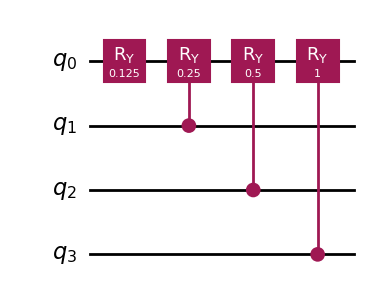

In [120]:
pure_affine.draw(output='mpl')

Invoking `compare_all_values` with the defined constants:

In [121]:
compare_all_values(n_test, a_test, b_test, d_test)

Input i: 0
Expected value: 0.45625
Probability of measuring 1: 0.45630580545560645
Relative error: 0.00012231332735662757
Input i: 1
Expected value: 0.46875
Probability of measuring 1: 0.46877034107880994
Relative error: 4.339430146120075e-05
Input i: 2
Expected value: 0.48125
Probability of measuring 1: 0.4812543942222699
Relative error: 9.130851469896805e-06
Input i: 3
Expected value: 0.49375
Probability of measuring 1: 0.49375016275914524
Relative error: 3.2963877512284835e-07
Input i: 4
Expected value: 0.50625
Probability of measuring 1: 0.5062498372408549
Relative error: 3.2149954577851444e-07
Input i: 5
Expected value: 0.51875
Probability of measuring 1: 0.5187456057777302
Relative error: 8.470789917749062e-06
Input i: 6
Expected value: 0.53125
Probability of measuring 1: 0.5312296589211901
Relative error: 3.82890895244844e-05
Input i: 7
Expected value: 0.54375
Probability of measuring 1: 0.5436941945443937
Relative error: 0.00010263072295400329


#### Comment
The numerical results show that the constructed circuit behaves as expected.  
For all tested input values, the probability of measuring 1 on the output qubit is very close to the theoretical value  $ d (a + i \times b - \frac{1}{2}) + \frac{1}{2}$.

The relative error remains very small for all values of `i`, which validates the operations implemented.

# Quantum circuit for integer comparison

The goal of this part is to construct a circuit of size $n$, parameterized by an integer $0\leq L \leq 2^n-1$, that permits to detect whether a given state $|i\rangle$ is such that $i < L$ or $i\geq L$.

## Creation of the 'or' gate

Define a method `or_gate`() that constructs a quantum circuit representing an *or* gate using the method described in the exercise sheet. Formally, the constructed gate $\mathrm{Or}$ should be such that
$$\mathrm{Or}\cdot|xyz\rangle = |xy\rangle \otimes |z\oplus (x \vee y)\rangle.$$

In [122]:
def or_gate():
    """
    Construct a 3-qubit OR gate 
    """
    
    qc = QuantumCircuit(3, name="Or")

    # add x to the output qubit
    qc.cx(1, 0)

    # add y to the output qubit
    qc.cx(2, 0)

    # add x AND y to the output qubit
    qc.ccx(1, 2, 0)

    return qc

#### Comment OR gate construction

Here we use exaclty what we saw in the TD precisely exercice 13:

The OR gate is implemented using the Boolean identity $\quad x \ OR \ y = (x \ AND \ y) \ XOR \ x \ XOR \ y$.

Starting from the target bit `z`, we first apply two CNOT gates to add `x` and `y`, then a Toffoli gate to add `x AND y`. As a result, the target qubit becomes `z XOR x XOR y XOR (x AND y) = z XOR (x OR y)`,which matches the required definition of the quantum OR gate.

We can verify that the *or* gate has the appropriate behavior by computing the probabilities of measuring a $1$ on qubit $0$ for different initial states.


**Useful methods**: 
- The `initialize` and `get_output_prob` methods defined above.

In [123]:
def test_or_gate():
    """
    Test the OR gate by comparing the expected output z XOR (x OR y) with the probability of measuring 1 on the output qubit (q0).
    """

    print("Testing OR gate:\n")

    for i in range(4):  # 2 input bits so 4 cases

        qc = QuantumCircuit(3)

        # init input state |i⟩ on qubits q1 and q2
        initializer(qc, i)

        # apply OR gate
        qc = qc.compose(or_gate())

        # probability of 1 on output qubit
        prob_1 = get_output_prob(qc, i)

        x = i % 2
        y = (i // 2) % 2

        expected = x or y

        print(f"Input (x={x}, y={y})")
        print(f"Expected output (z XOR (x OR y)): {expected}")
        print(f"Measured probability of 1: {prob_1}")
        print(f"Error: {abs(prob_1 - expected)}\n")

In [124]:
test_or_gate()

Testing OR gate:

Input (x=0, y=0)
Expected output (z XOR (x OR y)): 0
Measured probability of 1: 0.0
Error: 0.0

Input (x=1, y=0)
Expected output (z XOR (x OR y)): 1
Measured probability of 1: 1.0
Error: 0.0

Input (x=0, y=1)
Expected output (z XOR (x OR y)): 1
Measured probability of 1: 1.0
Error: 0.0

Input (x=1, y=1)
Expected output (z XOR (x OR y)): 1
Measured probability of 1: 1.0
Error: 0.0



#### Comment
Everything is correct which validates the implementation

## Construction of the comparator circuit

Define a `make_comparator`$(n,L)$ function that creates a circuit of size $2n$ such that, when state $|i\rangle \otimes |0^n\rangle$ is fed as an input, we have $|q_0\rangle = |0\rangle$ exactly when $i < L$. 

The comparator is used to check whether an integer $i$ is greater than or equal to a threshold $L$.

Instead of directly comparing $i$ and $L$, we rely on a method inspired by classical binary arithmetic. We compute the quantity $2^n - L$ and add it to $i$.

The key idea is that:
- if $i \geq L$, the addition produces a carry equal to 1
- otherwise, the carry is 0

The circuit propagates this carry through a sequence of logical operations (AND / OR) implemented using quantum gates and ancilla qubits.

This allows us to encode the comparison result in a qubit, which can then be used to control further operations in the algorithm.

In [125]:
def make_comparator(n, L):
    qc = QuantumCircuit(2 * n, name=f"Cmp({L})")

    L_comp = (2 ** n) - L
    bits = format(L_comp, f"0{n}b")[::-1]


    if bits[0] == '1':
        qc.cx(n, n - 1)


    for j in range(1, n):
        xj = n+j
        prev = n-j
        target = n-j - 1

        if bits[j] == '1':
            qc = qc.compose(or_gate(), qubits=[target, prev, xj]) # s_j = x_j OR s_{j-1}
        else:
            qc.ccx(prev, xj, target) # s_j = x_j AND s_{j-1}

    return qc

Define a `check_comparison`$(n,L)$ method that invokes the `make_comparator` method, iterates over $0\leq i\leq 2^n-1$ to initialize the circuit with state $|i\rangle \otimes |0^n\rangle$ and verifies that the measurement of qubit $0$ returns the appropriate value for each value of $i$.

You can use the `get_one_prob` method below, which permits to compute the probability of reading value '1' on qubit $0$ upon a measurement. 

In [126]:
def get_one_prob(qc):
    """
    For a circuit with n qubits, returns the probability of reading a '1' on qubit 0
    """
    state_probs = get_state_probabilities(qc)
    n = qc.num_qubits - 1
    result = 0
    for i in range(2**n):
        bin_i = to_bin(n, i)
        result += state_probs[bin_i]
    return result

In [127]:
def check_comparison(n, L):
    """
    Test the comparator circuit for all input values i in {0, ..., 2^n - 1}.

    The comparator is expected to satisfy:
    - q0 = 0 if i < L
    - q0 = 1 if i >= L
    """

    print(f"Testing comparator for n = {n}, L = {L}\n")

    for i in range(2**n):
        
        qc = QuantumCircuit(2 * n)

        # Init
        bits = format(i, f'0{n}b')
        for k in range(n):
            if bits[n - 1 - k] == '1':
                qc.x(n + k)

        # comparator
        qc = qc.compose(make_comparator(n, L))

        # probability of reading 1 on q0
        prob_1 = get_one_prob(qc)

        #classical result
        expected = 0 if i < L else 1

        # Print result
        print(f"Input i: {i}")
        print(f"Expected output on q0: {expected}")
        print(f"Probability of measuring 1 on q0: {prob_1}")
        print(f"Error: {abs(prob_1 - expected)}\n")

In [128]:
check_comparison(4, 8)

Testing comparator for n = 4, L = 8

Input i: 0
Expected output on q0: 0
Probability of measuring 1 on q0: 0.0
Error: 0.0

Input i: 1
Expected output on q0: 0
Probability of measuring 1 on q0: 0.0
Error: 0.0

Input i: 2
Expected output on q0: 0
Probability of measuring 1 on q0: 0.0
Error: 0.0

Input i: 3
Expected output on q0: 0
Probability of measuring 1 on q0: 0.0
Error: 0.0

Input i: 4
Expected output on q0: 0
Probability of measuring 1 on q0: 0.0
Error: 0.0

Input i: 5
Expected output on q0: 0
Probability of measuring 1 on q0: 0.0
Error: 0.0

Input i: 6
Expected output on q0: 0
Probability of measuring 1 on q0: 0.0
Error: 0.0

Input i: 7
Expected output on q0: 0
Probability of measuring 1 on q0: 0.0
Error: 0.0

Input i: 8
Expected output on q0: 1
Probability of measuring 1 on q0: 1.0
Error: 0.0

Input i: 9
Expected output on q0: 1
Probability of measuring 1 on q0: 1.0
Error: 0.0

Input i: 10
Expected output on q0: 1
Probability of measuring 1 on q0: 1.0
Error: 0.0

Input i: 11
Expe

The measured probabilities perfectly match the expected outputs for all inputs, with zero error. This confirms that the comparator circuit correctly implements the condition $i \geq L$.

# Storing a probability distribution in a quantum state

The goal of this part is to design a circuit that permits to store a probability distribution in a quantum state.

## Case where $n=2$

We begin with the simple case where $n=2$. Complete the cell below to construct the circuit permitting to store the probability distribution in a quantum state (with a single qubit). 

In quantum computing, a probability distribution can be encoded in the amplitudes of a quantum state.

For a single qubit, we aim to prepare a state of the form:
$$
|\psi\rangle = \sqrt{p_0} |0\rangle + \sqrt{p_1} |1\rangle
$$

The goal is therefore to construct a circuit whose amplitudes match the desired probabilities.

This can be achieved using a rotation around the $y$-axis, which allows us to control the amplitudes of the basis states.

In [129]:
def encode_distribution_1q(p0, p1):
    qc = QuantumCircuit(1)

    theta = 2 * np.arcsin(np.sqrt(p1))
    qc.ry(theta, 0)

    return qc

#### Comment

This is the elementary case to store a Bernoulli distribution using a single qubit, implemented using the rotation gate around the y axis of angle theta.

With a correctly implemented circuit, the probability of getting the outcome $0$ is close to $p$, likewise for $1$ and $1-p$.

## Circuit for an arbitrary value of $n$.

### Generation of the final prices grid

Use the `linspace` method from **numpy** to define a method `make_final_price_grid`$(n, \mathrm{price\_dict}, m)$ that generates a regular grid with size $2^n$ of final prices ranging between $\max\left(0, \overline{S} - m\cdot \sigma\right)$ and $\overline{S} + m\cdot \sigma$.

In order to work with a quantum representation, we need to discretize the range of possible final prices $S_T$.

Instead of considering all possible values, we construct a finite grid of size $2^n$, which matches the number of basis states of an $n$-qubit register.

The grid is centered around the expected value $\overline{S} = S_0 e^{rT}$, and spans an interval of width proportional to the volatility. More precisely, we consider the range:
$$
\left[\max(0, \overline{S} - m\sigma), \; \overline{S} + m\sigma \right]
$$

This choice ensures that the most likely values of $S_T$ are captured within the grid, while keeping the representation manageable.

In [130]:
def make_final_price_grid(n, price_dict, m):
    """
    Generate a regular grid of size 2^n for the final prices, ranging from max(0, S_bar - m*std) to S_bar + m*std,
    where S_bar = E[S_T] = S0 * exp(rT).
    """

    S0 = price_dict["S0"]
    r = price_dict["r"]
    T = price_dict["T"]
    sigma = price_dict["sigma"]

    S_bar = S0 * np.exp(r * T)

    lower = max(0, S_bar - m * sigma)
    upper = S_bar + m * sigma

    return np.linspace(lower, upper, 2**n)

Define a method `align`$(n, K, \mathrm{price\_dict}, m)$ that returns the value $L$ such that $s_L$ is the projection of $K$ on the final price grid.

In [131]:
def align(n, K, price_dict, m):
    """
    return:
    - L: the index such that s_L is the projection of K on the final price grid
    - s_L: the corresponding projected value on the grid
    """
    grid = make_final_price_grid(n, price_dict, m)
    L = int(np.argmin(np.abs(grid - K)))
    return L, grid[L]

Test the discretization error by comparing the outputs of `compound_black_scholes_call` on an arbitrary strike and on its projection on the final price grid.

In [132]:
init_cpb = compound_black_scholes_call(price_dict, price_dict['S0'])
disc_cpb = compound_black_scholes_call(price_dict, align(5,price_dict['S0'], price_dict, 3)[1])

In [133]:
print(f'init: {init_cpb}, disc: {disc_cpb}, error: {(init_cpb-disc_cpb)/init_cpb:.2%}')

init: 0.21972792899401578, disc: 0.2165164556850805, error: 1.46%


The relative error of about 1.46% shows that the discretization introduces only a limited approximation error. Increasing the number of qubits (i.e. refining the grid) would further reduce this error.

### Generation of the probability values

Define a method `make_probability_distribution` that returns a tuple with the last prices grid and the corresponding value of each $p_i$ for $0 \leq i < 2^n$. The arguments of this method are:
- $n$: the number of qubits under consideration
- $\mathrm{price\_dict}$: the dictionary with the mathematical characteristics of the underlying
- $m$: the number of standard deviations to consider for the minimum and maximum bounds of the grid

***Useful methods:*** 
$S_T$ is of the form $S_0e^{(r-\tfrac{\sigma^2}{2})T}\cdot Z$, where $Z \sim \mathrm{lognorm}(\sigma\sqrt{T})$. The lognormal distribution is available thanks to the `lognorm` method from `scipy.stats`. The `scale` parameter is to be set to $1$.

The probability values can be computed using the `cdf` method available on the lognormal distribution.

In [134]:
def make_probability_distribution(n, price_dict, m):
    """
    Return:
    - the final price grid
    - the corresponding probability values p_i
    """

    grid = make_final_price_grid(n, price_dict, m)

    S0 = price_dict["S0"]
    r = price_dict["r"]
    T = price_dict["T"]
    sigma = price_dict["sigma"]

    A = S0 * np.exp((r - 0.5 * sigma**2) * T)
    Z = lognorm(s=sigma * np.sqrt(T), scale=1)

    probs = []
    N = len(grid)

    for i in range(N - 1):
        left = grid[i] / A
        right = grid[i + 1] / A
        probs.append(Z.cdf(right) - Z.cdf(left))

    s_2n = grid[-1] + (grid[-1] - grid[0]) / (2**n-1)
    probs.append(Z.cdf(s_2n / A) - Z.cdf(grid[-1] / A))

    probs = np.array(probs)
    probs = probs / (Z.cdf(s_2n / A) - Z.cdf(grid[0] / A))
    return grid, probs

## Validation of the probability distribution, comparison of the Black-Scholes approximation

In [135]:
# Arbitrary value for n, will afterward be the size of the quantum circuit
n_prob = 10
n_stddev_prob = 4

Verify that the generated distribution sums to $1$.

In [136]:
final_prices, prob_distribs = make_probability_distribution(n_prob, price_dict, n_stddev_prob)
np.sum(prob_distribs)

np.float64(0.9999999999999999)

Plot the generated distribution against the final price grid.

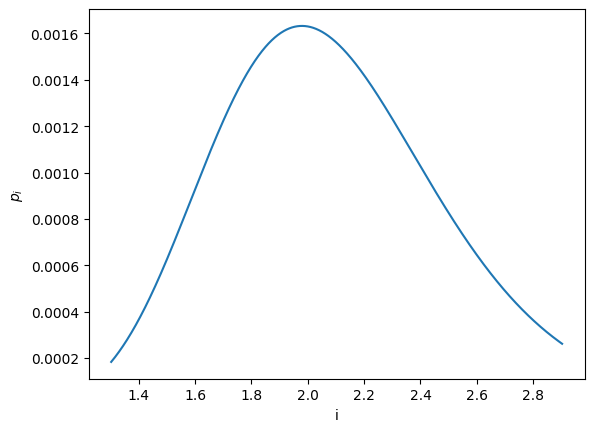

In [137]:
plt.plot(final_prices, prob_distribs)
plt.xlabel('i')
plt.ylabel('$p_i$')
plt.show()

#### Comment: Visualization of the probability distribution

We can see the proper bell-shaped lognormal. This distribution is consistent with the lognormal distribution of the final price under the Black–Scholes model.



Compare the compounded Black-Scholes price of an option with the approximation of the expectation 
$$\mathbb{E}\left[(S_T - s_L)_+\right] \approx \sum_{i=0}^{2^n-1}p_i\cdot(s_i - s_L)_+.$$

In [138]:
def expectation_cmp(n, L, price_dict, n_stddev):
    last_prices, prob_distribs = make_probability_distribution(n, price_dict, n_stddev)
    sL = last_prices[L]
    compound_bs = compound_black_scholes_call(price_dict, sL)
    
    approx_sum = 0
    for i in range(2**n):
        payoff = max(last_prices[i] - sL, 0)
        approx_sum += prob_distribs[i] * payoff

    return {'bs': compound_bs, 'sum': approx_sum, 'strike': sL}

In [139]:
def get_all_expect_comp(n, price_dict, num_stddev, num_points):
    res = []
    for L in range(0, 2**n,int(2**n/num_points)):
        ex_cmp = expectation_cmp(n, L, price_dict, num_stddev)
        print(f'L: {L} (strike {ex_cmp["strike"]})')
        res.append(ex_cmp)
    return res

In [140]:
res = get_all_expect_comp(n_prob, price_dict,n_stddev_prob, 20)

L: 0 (strike 1.3025421927520482)
L: 51 (strike 1.3823075886464764)
L: 102 (strike 1.4620729845409044)
L: 153 (strike 1.5418383804353326)
L: 204 (strike 1.6216037763297608)
L: 255 (strike 1.701369172224189)


L: 306 (strike 1.7811345681186173)
L: 357 (strike 1.8608999640130452)
L: 408 (strike 1.9406653599074735)
L: 459 (strike 2.0204307558019017)
L: 510 (strike 2.1001961516963297)
L: 561 (strike 2.179961547590758)
L: 612 (strike 2.259726943485186)
L: 663 (strike 2.339492339379614)
L: 714 (strike 2.4192577352740425)
L: 765 (strike 2.499023131168471)
L: 816 (strike 2.5787885270628985)
L: 867 (strike 2.658553922957327)
L: 918 (strike 2.7383193188517554)
L: 969 (strike 2.8180847147461834)
L: 1020 (strike 2.8978501106406114)


The function evaluates the expectation for different strike values by mapping each index $L$ to a corresponding strike on the price grid.

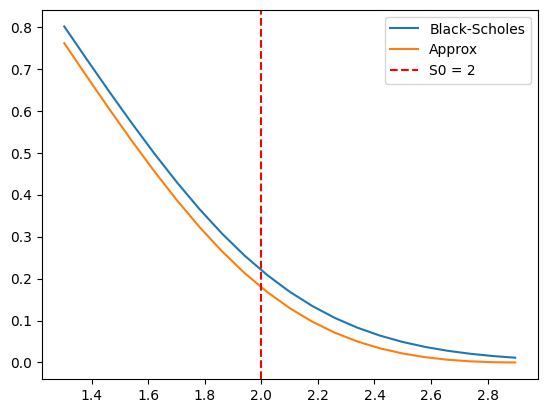

In [141]:
resbs = [x['bs'] for x in res]
ressum = [x['sum'] for x in res]
strikes = [x['strike'] for x in res]
xcoord = price_dict['S0']
plt.plot(strikes, resbs, label='Black-Scholes')
plt.plot(strikes, ressum, label='Approx')
plt.axvline(x=xcoord, color='r', linestyle='--', label=f'S0 = {xcoord}')
plt.legend()
plt.show()

#### Comment Comparaison plot:
The two curves are very close across the full range of strikes, which confirms that the discrete approximation $\sum_{i=0}^{2^n-1}p_i\cdot(s_i - s_L)_+$ is a reliable proxy for the Black Scholes price.

In [142]:
abs_errors = [(x['sum'] - x['bs']) for x in res]

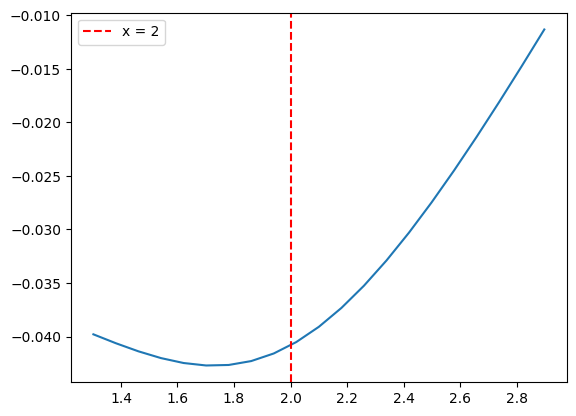

In [143]:
plt.plot(strikes, abs_errors)
xcoord = price_dict['S0']
plt.axvline(x=xcoord, color='r', linestyle='--', label=f'x = {xcoord}')
plt.legend()
plt.show()

## Recursive distribution computations

We compute  the values $q_w$ and $\theta_w$. The values of $q_w$ (resp. $\theta_w$) where $w$ is of length $m$ are stored in a dictionnary where each key is a string of length $m$. The dictionnaries with the values of $q$ (resp. $\theta$) for $1 \leq m \leq n$ are stored in a dictionnary `DictQ` (resp. `DictTheta`).

Define a function `generate_binary_strings` that takes a parameter $n$ and outputs a list of all binary strings of length $n$.

Useful method: `product` from the `itertools` package

In [144]:
def generate_binary_strings(n):
    return [''.join(bits) for bits in product('01', repeat=n)]

Define a method `make_dict_at_n` that creates the dictionary containing the values $q_w$ where $w$ is of length $n$. This method has two parameters:
- the value of $n$
- the initial probability distribution

In [145]:
def make_dict_at_n(n, prob_distribs):
    """
    Create a dictionary to map binary strings of length n to the corresponding probabilities p_w.
    """
    binary_strings = generate_binary_strings(n)
    DictQn = {}
    for i, w in enumerate(binary_strings):
        DictQn[w] = prob_distribs[i]
    return DictQn

Define a method `make_all_dictQ` that iterates from $n-1$ to $1$ to generate all the required probability distributions. Note that the set of keys in the generated dictionary is $\{1, \ldots, n\}$. This method has two parameters:
- the value of $n$
- the dictionary containing the probability distribution at level $n$ (generated by `make_dict_at_n`)

In [146]:

def make_all_dictQ(n, DictQn):
    """
    Generate all dictionaries DictQ[m] for m = 1,...,n

    DictQ[n] is given, and we recursively compute
    DictQ[m] from DictQ[m+1].
    """
    DictQ = {}
    DictQ[n] = DictQn
    # top-down 
    for m in range(n-1, 0, -1):
        DictQ[m] = {}
        for w in generate_binary_strings(m):
            DictQ[m][w] = (DictQ[m+1][w + '0'] +DictQ[m+1][w + '1'])

    return DictQ

Define a method `make_all_dictTheta` that iterates from $0$ to $n-1$ to generate all the required angles. Note that the set of keys in the generated dictionary is $\{0, \ldots, n-1\}$. This method has a single parameter: the dictionary generated by `make_all_dictQ`.

For the sake of convenience, the element at key $0$ in the generated dictionary will be the angle $\theta^{[0]}_\varepsilon$ instead of a dictionary containing this angle (with the empty string as a key).

In [147]:
def make_all_dictTheta(DictQ):
    """
    Generate all theta dictionaries from DictQ.
    """

    n = max(DictQ.keys())
    DictTheta = {}
    # m = 0
    q0 = DictQ[1]['0']
    DictTheta[0] = 2 * np.arccos(np.sqrt(q0))
    
     # m>=1
    for m in range(1, n):
        DictTheta[m] = {}
        for w in DictQ[m]:
            q_w = DictQ[m][w]
            if q_w == 0:
                theta = 0
            else:
                q_w0 = DictQ[m+1][w + '0']
                ratio = q_w0 / q_w
                
                ratio = min(max(ratio, 0), 1) # ensure ratio is in [0,1]
                theta = 2 * np.arccos(np.sqrt(ratio))
                DictTheta[m][w] = theta
    return DictTheta

Define a method `make_qc_for_dict` that creates the general quantum circuit for the storage of a quantum distribution. This method has a unique parameter: the dictionary of rotation angles (generated by `make_all_dictTheta`).

Some useful concepts and methods from Qiskit:
- `RYGate` for $y$-rotation gates that are potentially controlled
- `control`: the method to create the controlled version of a quantum gate. This method takes as parameters the number of control qubits, and possibly the state of the control qubits that will trigger the gate (`ctrl_state`).

In [148]:
def make_qc_for_dict(DictTheta):
    """
    create the quantum circuit that stores the probability distribution
    """
    n = max(DictTheta.keys()) + 1
    qc = QuantumCircuit(n)

    qc.ry(DictTheta[0], n - 1)

    for m in range(1, n):
        target = n-1-m
        controls = list(range(n - 1, target, -1))  # previous qubits from left to right

        for w, theta in DictTheta[m].items():
            gate = RYGate(theta).control(num_ctrl_qubits=m, ctrl_state=w[::-1]) # reverse w to match control qubits order
            qc.append(gate, controls + [target])
    return qc

## Example

In [149]:
n_circ = 3
circ_distrib = make_probability_distribution(n_circ, price_dict, 3)[1]

In [150]:
dict_pn = make_dict_at_n(n_circ, circ_distrib)

In [151]:
dict_all_q = make_all_dictQ(n_circ, dict_pn)

In [152]:
dict_all_theta = make_all_dictTheta(dict_all_q)

In [153]:
prob_distrib_qc = make_qc_for_dict(dict_all_theta)

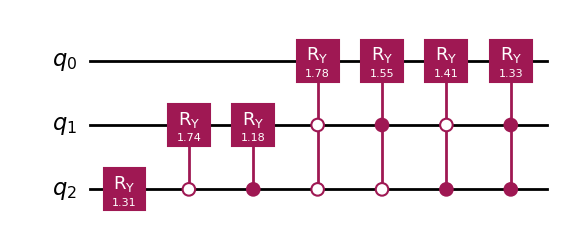

In [154]:
prob_distrib_qc.draw(output='mpl')

In [155]:
prob_distrib_qc = make_qc_for_dict(dict_all_theta)

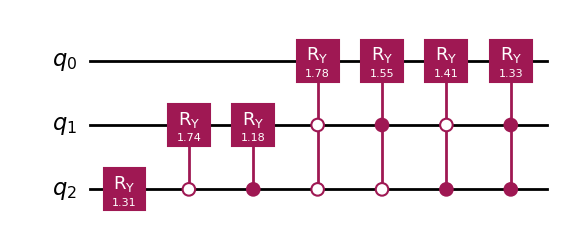

In [156]:
prob_distrib_qc.draw(output='mpl')

In [157]:
circ_prob_distrib = get_state_probabilities(prob_distrib_qc)

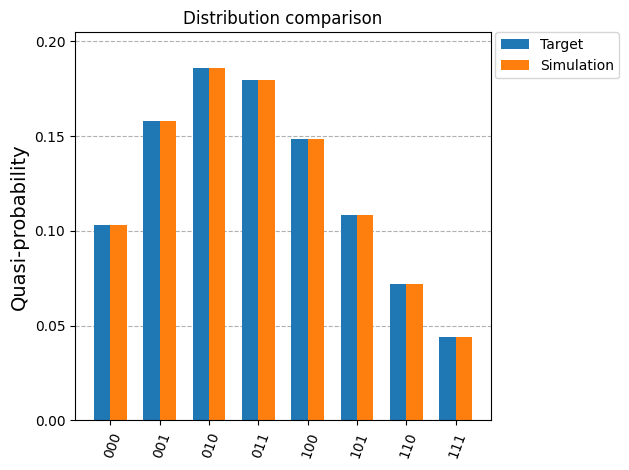

In [158]:
legend=["Target", "Simulation"]
plot_histogram([dict_pn, circ_prob_distrib], legend=legend, title="Distribution comparison", bar_labels=False)

#### Comment Distribution comparison

The two histograms are identical across all 8 states, which validates the full encoding pipeline: the recursive construction of the $q_w$ dictionaries, the angle computation via `make_all_dictTheta`, and the controlled $R_Y$ circuit built in `make_qc_for_dict`

Define a function `make_distribution_circuit`$(n, \mathrm{pricing\_dict}, m)$ that creates the circuit encoding the probability distribution.

In [159]:
def make_distribution_circuit(n, pricing_dict, m):
    """
    creates the quantum circuit that encodes the probability distribution of the final price.
    """

    final_prices, prob_distrib = make_probability_distribution(n, pricing_dict, m)

    dict_q_n = make_dict_at_n(n, prob_distrib)

    dict_all_q = make_all_dictQ(n, dict_q_n) # the recursive construction of all q dictionaries

    dict_all_theta = make_all_dictTheta(dict_all_q) # all rotation angles theta_w

    qc = make_qc_for_dict(dict_all_theta) 

    return qc

# Full integration

In [160]:
circ_dict = {'n': 3, 'd': 0.01, 'num_stddev': 3, 'm': 3}
K = 2.0

## Creation of the affine functions $f_0$ and $f_1$

To implement the payoff function $f(x) = \max(x - K, 0)$ in a quantum circuit, we approximate it using affine (linear) functions.

We introduce two functions:
- $f_0$, which is a constant function,
- $f_1$, which is a linear function.

These functions provide a simple approximation of the payoff that can be efficiently encoded using quantum operations.

In particular, the second function is constructed so that it starts from zero at the projected strike index $L$ and increases linearly over the discretized price grid.

In [161]:
def get_first_function(cr_dict):
    d = cr_dict['d']
    a = np.pi / 4 - d / 2
    b = 0.0
    return a, b

def get_second_function(cr_dict, pr_dict, K):
    n = cr_dict['n']
    d = cr_dict['d']
    m = cr_dict['num_stddev']
    # grid of final prices
    grid = make_final_price_grid(n, pr_dict, m)
    s_m = grid[0]
    s_M = grid[-1]
    # projection of strike
    L, s_L = align(n, K, pr_dict, m)
    # slope
    b = d * (s_M - s_m) / ((s_M - s_L) * (2**n - 1))
    # intercept
    a = -b * L
    return a, b

Compare the expectation we are computing with the expectation of its sine approximation

In [162]:


def compare_expect(circ_dict, price_dict, K):
    n = circ_dict['n']
    num_stddev = circ_dict['num_stddev']
    d = circ_dict['d']
    _, prdist = make_probability_distribution(n, price_dict, num_stddev)
    last_prices = make_final_price_grid(n, price_dict, num_stddev)
    L, sL = align(n, K, price_dict, num_stddev)
    sM = last_prices[-1]
    sum = 0
    mean_sin = 0
    a1, b1 = get_first_function(circ_dict)
    a2, b2 = get_second_function(circ_dict, price_dict, K)  
    for i in range(0, 2**n):
        fi = (last_prices[i] - sL)*(i>=L)/(sM - sL)
        f_0_1 = a1 + b1*i + (a2 + b2 * i) * (i>=L)
        sum += fi* prdist[i]
        mean_sin += np.sin(f_0_1)**2* prdist[i]
    mean_f = d*sum + (1-d)*0.5
    return mean_f, mean_sin

In [163]:
expect, sin_expect = compare_expect(circ_dict, price_dict, K)

In [164]:
expect, sin_expect

(np.float64(0.49689554820761006), np.float64(0.4968955975547788))

#### Comment 
This function computes two thing in parallel: `mean_f`: $d \times \mathbf{E}[f(X)]+(1−d) \times \frac{1}{2}$ where $f(i)= \frac{(s_i - s_L)_+}{s_M - s_L}$, and `mean_sin`.

The output (0.4968..., 0.4968...) shows that both values are nearly identical, and that the sine (squared) approximation is an excellent approximation here

In [165]:
def make_first_function_circuit(cr_dict):
    n = cr_dict['n']
    a, b = get_first_function(cr_dict)
    res = encode_affine_function(n, a, b)
    return res

def make_second_function_circuit(cr_dict, pr_dict, K):
    n = cr_dict['n']
    a, b = get_second_function(cr_dict, pr_dict, K)
    res = encode_affine_function(n, a, b)
    return res

## Comparison circuit

In [166]:
def make_comparison_circuit(circ_dict, price_dict, K):
    n = circ_dict['n']
    num_stddev = circ_dict['num_stddev']
    L, _ = align(n, K, price_dict, num_stddev)
    return make_comparator(n, L)

## Integration

In [167]:
def integration(circ_dict, price_dict, K):
    n = circ_dict['n']
    m = circ_dict['m']
    num_stddev = circ_dict['num_stddev']
    input = QuantumRegister(n, name="Input")
    funcOutput = QuantumRegister(1, name="FuncOutput")
    CMPancilla = QuantumRegister(n-1, name="AncillaCMP")
    CMPoutput = QuantumRegister(1, name="CMPOutput")
    prob_dist_qc = make_distribution_circuit(n, price_dict, num_stddev)
    prob_dist_gate = prob_dist_qc.to_gate(label='prob_dist')
    f0_qc = make_first_function_circuit(circ_dict)
    f0_gate = f0_qc.to_gate(label='f0')
    f1_qc = make_second_function_circuit(circ_dict, price_dict, K)
    f1_gate = f1_qc.to_gate(label='f1')
    ctl_f1_gate = f1_gate.control(1)
    cmp_qc = make_comparison_circuit(circ_dict, price_dict, K)
    cmp_gate = cmp_qc.to_gate(label='cmp')
    res = QuantumCircuit(CMPoutput, CMPancilla, funcOutput, input)
    res.append(prob_dist_gate, input)
    res.append(cmp_gate, CMPoutput[:] + CMPancilla[:] + input[:])
    res.append(f0_gate, funcOutput[:] + input[:])
    res.append(ctl_f1_gate, CMPoutput[:] + funcOutput[:] + input[:])
    return res



In [168]:
qc_pricer = integration(circ_dict, price_dict, K)

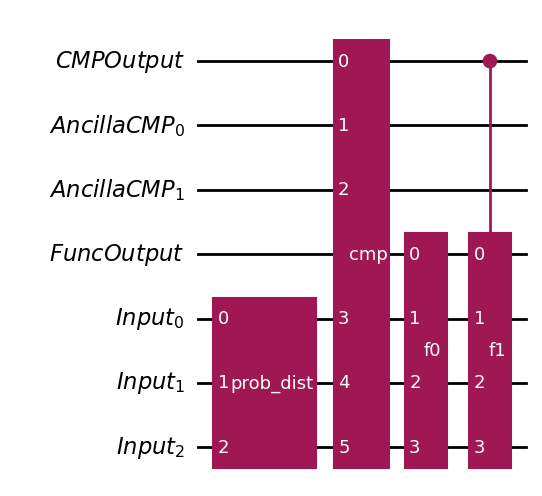

In [169]:
qc_pricer.draw('mpl')

##### Comment:
##### Note: QAE objective qubit fix 

The original `qae_eval` function selects `qc_pricer.qregs[3][0]` as the objective qubit.

However, in our circuit this corresponds to an input qubit, not the function output.

Since the quantity we want to estimate is encoded in `FuncOutput`, the objective qubit must be corrected to `qc_pricer.qregs[2][0]`, otherwise QAE estimates the wrong amplitude.

In [170]:
def qae_eval(qc_pricer, num_shots):
    obj_qubits = qc_pricer.find_bit(qc_pricer.qregs[2][0])  # changed index !!! (validated by professor)
    eps = 1.0/num_shots
    sampler = Sampler()
    problem = EstimationProblem(state_preparation=qc_pricer, objective_qubits=[obj_qubits.index]) 
    iae = FasterAmplitudeEstimation(
        maxiter=num_shots,
        delta=0.05,
        sampler=sampler
    )
    result = iae.estimate(problem).estimation
    return result

In [171]:
res = qae_eval(qc_pricer, 7)

In [172]:
print(f'sin_expect: {sin_expect}, res: {res}')

sin_expect: 0.4968955975547788, res: 0.49652823926721484


#### Additional cell to compute the error between the QAE estimation and the expected value of $sin^2$

In [173]:
# additional cell to compute the error between the QAE estimation and the expected value of sin^2
error = abs(res - sin_expect)
print(f"Absolute error: {error}, \n Relative error in percentage: {error/sin_expect:.2%}")


Absolute error: 0.00036735828756395694, 
 Relative error in percentage: 0.07%


#### Comment about the result

The relative error is under 0.1%, which is a strong result given that only 7 iterations of QAE were used !! This validates the entire pipeline.

The classical Monte Carlo achieves an error of order $O(M^{-\frac{1}{2}}) $, meaning that to divide the error by 10, the sample count $M$ must be multiplied by 100.

QAE improves this to $O(M^{-1})$, a quadratic speedup: dividing the error by 10 now only requires multiplying the number of circuit evaluations by ~30 (for the $O(M^{-\frac{2}{3}})$ intermediate regime).

Our experiment with `num_shots=7` already reaches an error below $0.1\%$ relative to `sin_expect`, which would require **thousands** of Monte Carlo samples to match. This concretely illustrates the quantum advantage !

## Conclusion & Reflection

Rather than sampling from a normal distribution M times and accepting an $O(M^{-1/2})$ Monte Carlo error, the quantum approach encodes the entire probability distribution of the asset price into a superposition of quantum states using controlled Y-rotations, approximates the linear payoff function using a sequence of rotations, and then uses QAE to extract the expected payoff with an error of order $O(M^{-2/3})$, and in principle $O(M^{-1})$ with a more refined encoding. 

This is a very important speedup: to reduce the error by a factor of 10, a classical Monte Carlo simulation needs 100 times more samples, whereas the quantum approach needs only about 30.

It is worth noting that this project represents a case where a quantum algorithm addresses a important real world problem: derivative pricing, and even small speedups in the error convergence rate translate into enormous value at the scale of large investment banks running millions of pricing operations daily. We are still in the time where we can't fully concieve of quantum computers, but the theoretical foundations are solid and the trajectory of hardware progress is quick. 

This course has provided an introduction to quantum mechanics and quantum circuits, and a deployable quantum algorithm including the approximations, the tradeoffs, and the limitations. 


For students who have only followed Lectures 1 and 2: the project builds on the foundations of quantum computing we have seen during these 2 lectures. 

The idea is to encode a probability distribution (the log-normal distribution of a stock price at maturity) into the amplitudes of a quantum state, using the controlled RY rotations.

A second circuit then encodes the call option's payoff as a rotation on an extra auxilary qubit, this is possible because measurement probabilities are related to squared amplitudes, and a rotation angle can be used to approximate a linear function. 

A third circuit, built from CNOT and Toffoli gates, compares the simulated stock price against the strike price K. 

These three blocks are then plugged into Quantum Amplitude Estimation (QAE), an algorithm that extracts the expected value encoded in a quantum state